In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [4]:
words = open('../datasets/names.txt', 'r').read().splitlines()
len(words)
chars = sorted(set(list(''.join(words))))
print(chars)
stoi = {s : i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
print(stoi)

itos = {i: s for s,i in stoi.items()}
print(itos)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# dataset
block_size = 3
X,Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        iy = stoi[ch]
        X.append(context)
        Y.append(iy)
        print(f"{''.join([itos[i] for i in context])} -> {itos[iy]}")
        context = context[1:] + [iy]
X =torch.tensor(X)
Y = torch.tensor(Y)
X.shape, X.dtype, Y.shape, Y.dtype

emma
... -> e
..e -> m
.em -> m
emm -> a
mma -> .
olivia
... -> o
..o -> l
.ol -> i
oli -> v
liv -> i
ivi -> a
via -> .
ava
... -> a
..a -> v
.av -> a
ava -> .
isabella
... -> i
..i -> s
.is -> a
isa -> b
sab -> e
abe -> l
bel -> l
ell -> a
lla -> .
sophia
... -> s
..s -> o
.so -> p
sop -> h
oph -> i
phi -> a
hia -> .


(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [6]:
# build embedding lookup table C, one entry per char and 2 cells for each
C = torch.randn((27, 2))
C.shape

torch.Size([27, 2])

In [7]:
# ways to address embedding:
# single element address:
print(C[5])

oneh = F.one_hot(torch.tensor(5), num_classes=27).float()
print(oneh.shape)
print(oneh)

# the same single element address via onehot:
print(oneh @ C)

#address multiple embeddings:
mult = C[[5,6,7,7,7]]
print(mult)
print(mult.shape)

#address through multi dim vector:
print(C[X].shape) #fetch embedding for every symbol for every char in our block

#positions will match, for ex, value at 13,2 is 1:
print(X[13,2])
#and it will be at the same position in C[X]:
print(C[X][13,2])
print(C[1])

#create fully mapped embeddings:
emb = C[X]
print(emb.shape)

tensor([-0.5950,  0.1285])
torch.Size([27])
tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([-0.5950,  0.1285])
tensor([[-0.5950,  0.1285],
        [ 0.3355,  0.6701],
        [ 0.2753, -0.4779],
        [ 0.2753, -0.4779],
        [ 0.2753, -0.4779]])
torch.Size([5, 2])
torch.Size([32, 3, 2])
tensor(1)
tensor([-1.1034,  0.0916])
tensor([-1.1034,  0.0916])
torch.Size([32, 3, 2])


In [8]:
# building hidden layer

#6 because our sequence length is 3 chars and each has 2 embeddings, so 3 * 2, 
# 100 is arbitrary number of neurons
W1 = torch.randn([6, 100]) 
b1 = torch.randn(100)

# to feed embedding which is Nx3x2 we need to convert it to Nx6 so it can go into our 6x100 neurons
# one way to to do is is through unbind and then cat:
torch.cat(torch.unbind(emb, 1), 1).shape 
# another way is through view which is faster:
emb.view([32,6]).shape
# the view method provides a way to represent tensor as any dimensional as long as number of dimensions match 
# the original (32 * 2 * 3 = 32 * 6)
emb.view([32,6]) == torch.cat(torch.unbind(emb, 1), 1)

# so to get hidden neurons:
h = torch.tanh(emb.view(32, 6) @ W1 + b1)
print(h.shape)

#instead of hardcoding 32, we can use number -1 which hints pytorch to derive missing dim:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
print(h.shape)



torch.Size([32, 100])
torch.Size([32, 100])


In [9]:
#building out layer
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
logits = h @ W2 + b2
print(logits.shape)

counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
print(probs.shape)

# now fetch probabilities calculated by our NN and weights for actual labels for current inputs
print(probs[torch.arange(32), Y].shape)

# for loss we use negative log likelihood loss:
loss = -probs[torch.arange(32), Y].log().mean()
print(loss)
# now there is built in func in pytorch that does the same classification as neg ll loss:
print(F.cross_entropy(logits, Y))


torch.Size([32, 27])
torch.Size([32, 27])
torch.Size([32])
tensor(19.6434)
tensor(19.6434)


## now everything the same but without extra temporary expressions and explanations

In [10]:
# dataset
block_size = 3
X,Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        iy = stoi[ch]
        X.append(context)
        Y.append(iy)
        context = context[1:] + [iy]
X =torch.tensor(X)
Y = torch.tensor(Y)
X.shape, X.dtype, Y.shape, Y.dtype
print(X.shape)
print(Y.shape)

#NN
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn([6, 100], generator=g) 
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
print("total params:", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


torch.Size([228146, 3])
torch.Size([228146])
total params: 3481


In [11]:
# SGD
for k in range(100):
    # forward
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # step
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

3.589251756668091


In [12]:

# SGD loop with minibatch
# 32 is the batch size here
for k in range(10000):
    ix = torch.randint(0, X.shape[0], (32,))
    # forward
    emb = C[X[ix]] # embeddings only for indexes from batch size
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix]) # labels only for indexes from batch size

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # step
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item()) # loss only for this minibatch

2.349641799926758


In [13]:
#eval loss for full dataset:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y) # labels only for indexes from batch size
print(loss.item())


2.4974145889282227


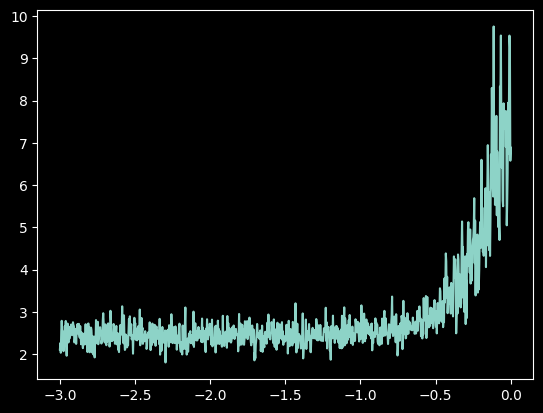

In [14]:
# finding a good learning rate:
lre = torch.linspace(-3, 0, 1000)
lrs =  10 ** lre # creates candidates for learning rates to test on (from 0.001 to 1)

# containers to collect data:
lri, lossi = [], []
for k in range(1000):
    ix = torch.randint(0, X.shape[0], (32,))
    # forward
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    lri.append(lre[k])
    lossi.append(loss.item())
    # backward
    for p in parameters:
        p.grad = None
    loss.backward()
    # step
    for p in parameters:
        p.data += -lrs[k] * p.grad
        

plt.plot(lri, lossi)
# if we reset weights before, graph should display a stable valley somewhere, inside that valley are good values to use as LR
# in our case valley is in between -1.3, -.04, so anything from that valley should be good, eg: 10 ** -1.0 = 0.1

## Introducing splits of datasets
Datasets often split into training set, dev/validation set and test set, usual proportion is 80%, 10%, 10%

In [15]:
def build_dataset(words):
    block_size = 3
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            iy = stoi[ch]
            X.append(context)
            Y.append(iy)
            context = context[1:] + [iy]
    X =torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, X.dtype, Y.shape, Y.dtype)
    return X,Y

random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
print(len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])



32033
torch.Size([182625, 3]) torch.int64 torch.Size([182625]) torch.int64
torch.Size([22655, 3]) torch.int64 torch.Size([22655]) torch.int64
torch.Size([22866, 3]) torch.int64 torch.Size([22866]) torch.int64


In [16]:
#redefine NN, this time with more hidden neurons:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn([6, 300], generator=g) 
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
print("total params:", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


total params: 10281


In [17]:
#now perform training and validation on these subsets

for k in range(30000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward
    emb = C[Xtr[ix]] # embeddings only for indexes from batch size
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) # labels only for indexes from batch size

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # step
    for p in parameters:
        p.data += -0.01 * p.grad
print(loss.item()) # loss only for this minibatch

2.8221263885498047


In [18]:
#eval loss for dev dataset:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev) # labels only for indexes from batch size
print(loss.item())


2.4574599266052246


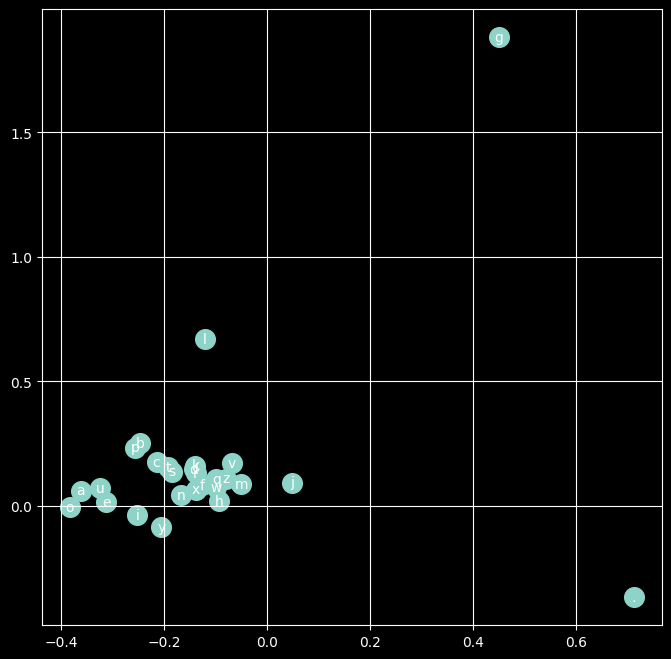

In [19]:
# lets visualize embeddings:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

## now lets increase size of embeddings to 10

In [20]:
#redefine NN, this time with more hidden neurons:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
W1 = torch.randn([30, 200], generator=g) 
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
print("total params:", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


total params: 11897


In [21]:
# containers for loss tracking
lri,lossi,stepi = [], [], []

In [22]:
#now perform training and validation on these subsets

for i in range(30000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward
    emb = C[Xtr[ix]] # embeddings only for indexes from batch size
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) # labels only for indexes from batch size

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # step
    for p in parameters:
        p.data += -0.005 * p.grad
    stepi.append(i)
    lossi.append(loss.log10().item())
print(loss.item()) # loss only for this minibatch

3.898662805557251


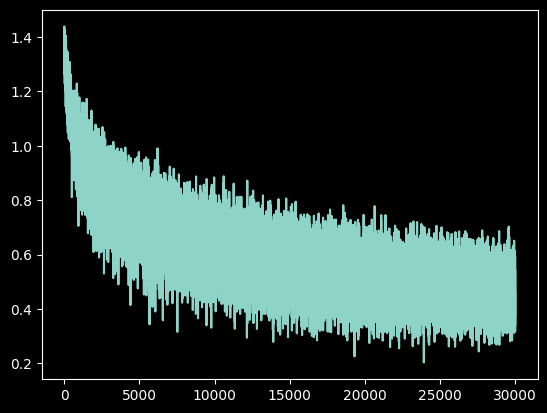

In [23]:
plt.plot(stepi, lossi)

In [24]:
#eval loss for dev dataset:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev) # labels only for indexes from batch size
print(loss.item())


2.918586254119873
